In [61]:
import kagglehub
import os
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import classification_report, f1_score, roc_curve, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imblearn_Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

mpl.rcParams['figure.dpi'] = 150
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette('cubehelix')

In [62]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
data_path = os.listdir(path)[0]
full_path = os.path.join(path, data_path)
print(f"Full Path: {full_path}")

Full Path: C:\Users\ASUS\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1\WA_Fn-UseC_-Telco-Customer-Churn.csv


In [63]:
df = pd.read_csv(r"C:\Users\ASUS\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [64]:
df.shape

(7043, 21)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [66]:
totalCharges_mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
none_numeric_vals = df.loc[totalCharges_mask, 'TotalCharges'].unique()

print(f"TotalCharges Column Bad Values : {none_numeric_vals}")

TotalCharges Column Bad Values : [' ']


In [67]:
df = df[~totalCharges_mask]
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

print(f"TotalCharges Column New DataType: {df['TotalCharges'].dtype}")

TotalCharges Column New DataType: float64


In [68]:
df.drop(columns='customerID', inplace=True, errors='ignore')

In [69]:
numeric_cols = df.select_dtypes(include='number').columns.drop('SeniorCitizen').tolist()
df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [70]:
categorical_cols = df.select_dtypes(include=['object']).columns.drop('Churn').tolist()
categorical_cols.append('SeniorCitizen')

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== gender =====
gender
Male      3549
Female    3483
Name: count, dtype: int64

===== Partner =====
Partner
No     3639
Yes    3393
Name: count, dtype: int64

===== Dependents =====
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

===== PhoneService =====
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

===== MultipleLines =====
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

===== InternetService =====
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

===== OnlineSecurity =====
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

===== OnlineBackup =====
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

===== DeviceProtection =====
DeviceProtection
No                     3094
Yes           

In [71]:
LABELS_FONT_SIZE = 10
TITLE_FONT_SIZE = 12
SUP_TITLE_FONT_SIZE = 20
FONT_WEIGHT = 'bold'
COLOR = 'lightblue'
PALETTE = 'Blues'

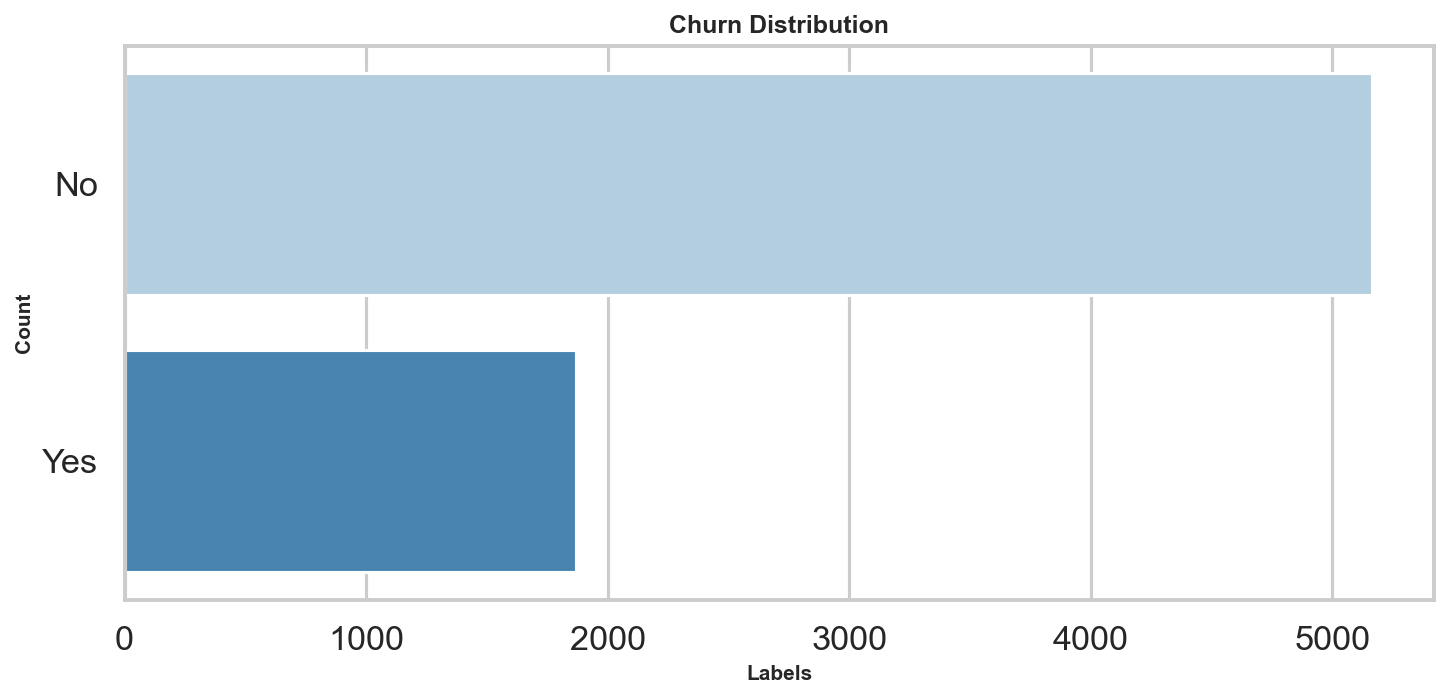

In [72]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.countplot(data=df, y='Churn', ax=ax, palette=PALETTE, legend=False, hue='Churn')

ax.set_title('Churn Distribution', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xlabel('Labels', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_ylabel('Count', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.tight_layout()
plt.show()

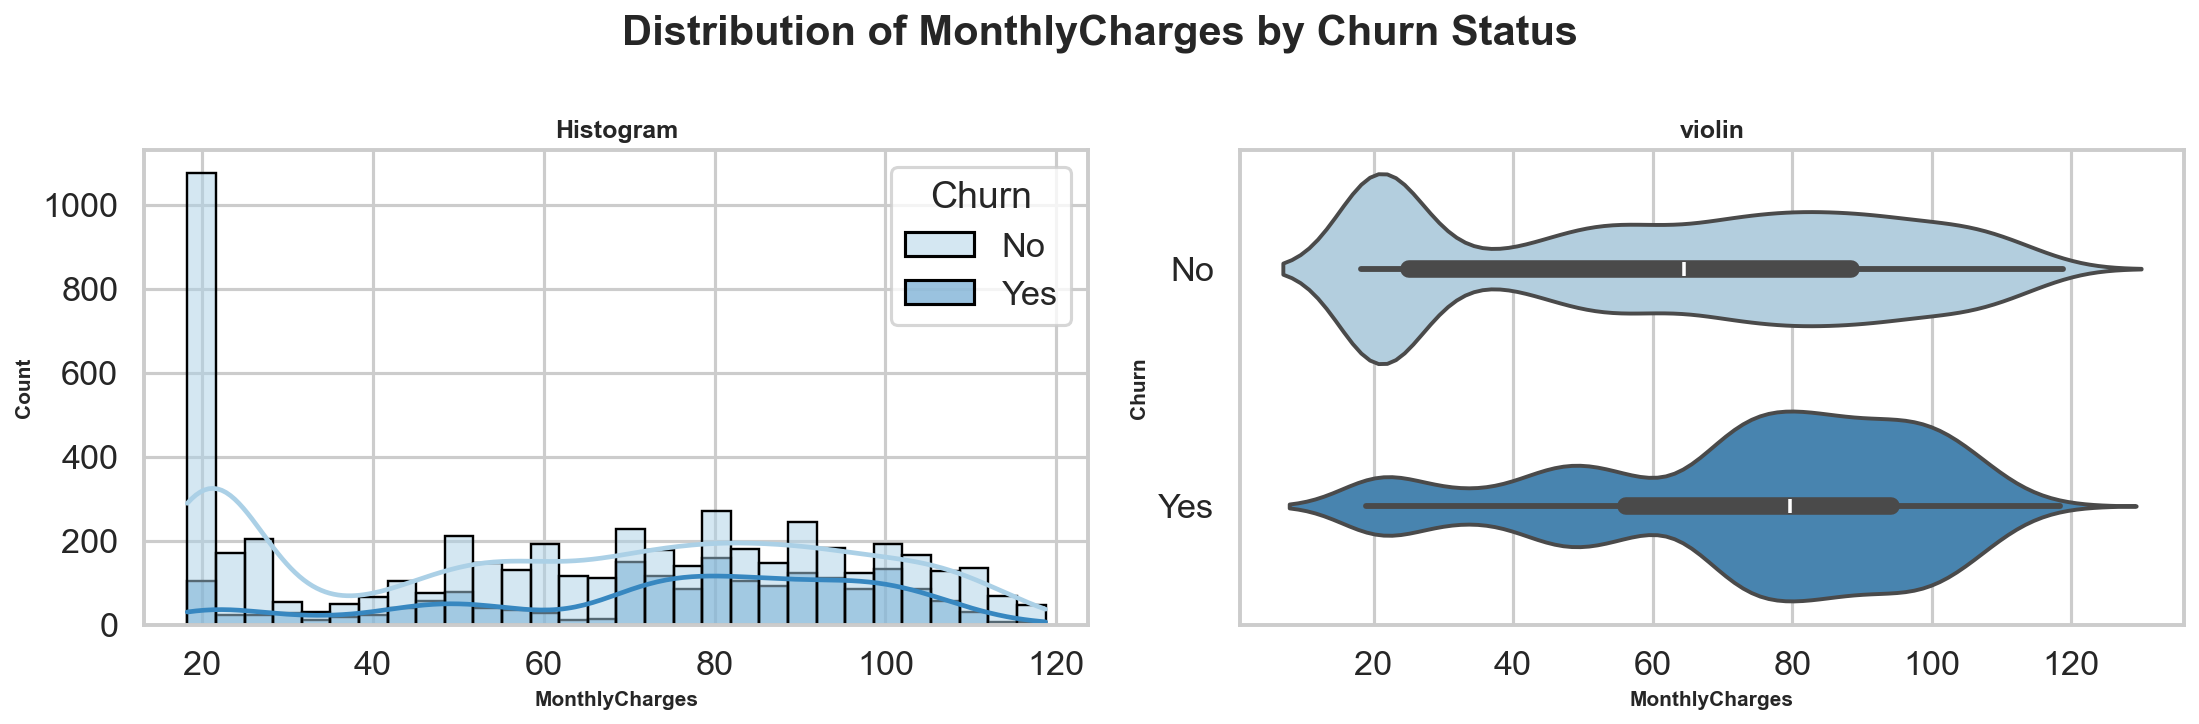

In [73]:
fig, axes = plt.subplots(figsize=(15, 5), ncols=2)
axes = axes.ravel()

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[0], 
             palette=PALETTE, bins=30, edgecolor='black', alpha=0.5)

sns.violinplot(data=df, x='MonthlyCharges', y='Churn', hue='Churn', 
               palette=PALETTE, ax=axes[1])

plt.suptitle('Distribution of MonthlyCharges by Churn Status', fontsize=SUP_TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)

for ax in axes:
    ax.set_xlabel(ax.get_xlabel(), fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
    
axes[0].set_title('Histogram', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
axes[0].set_ylabel('Count', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)

axes[1].set_title('violin', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
axes[1].set_ylabel('Churn', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)

plt.tight_layout()
plt.show()

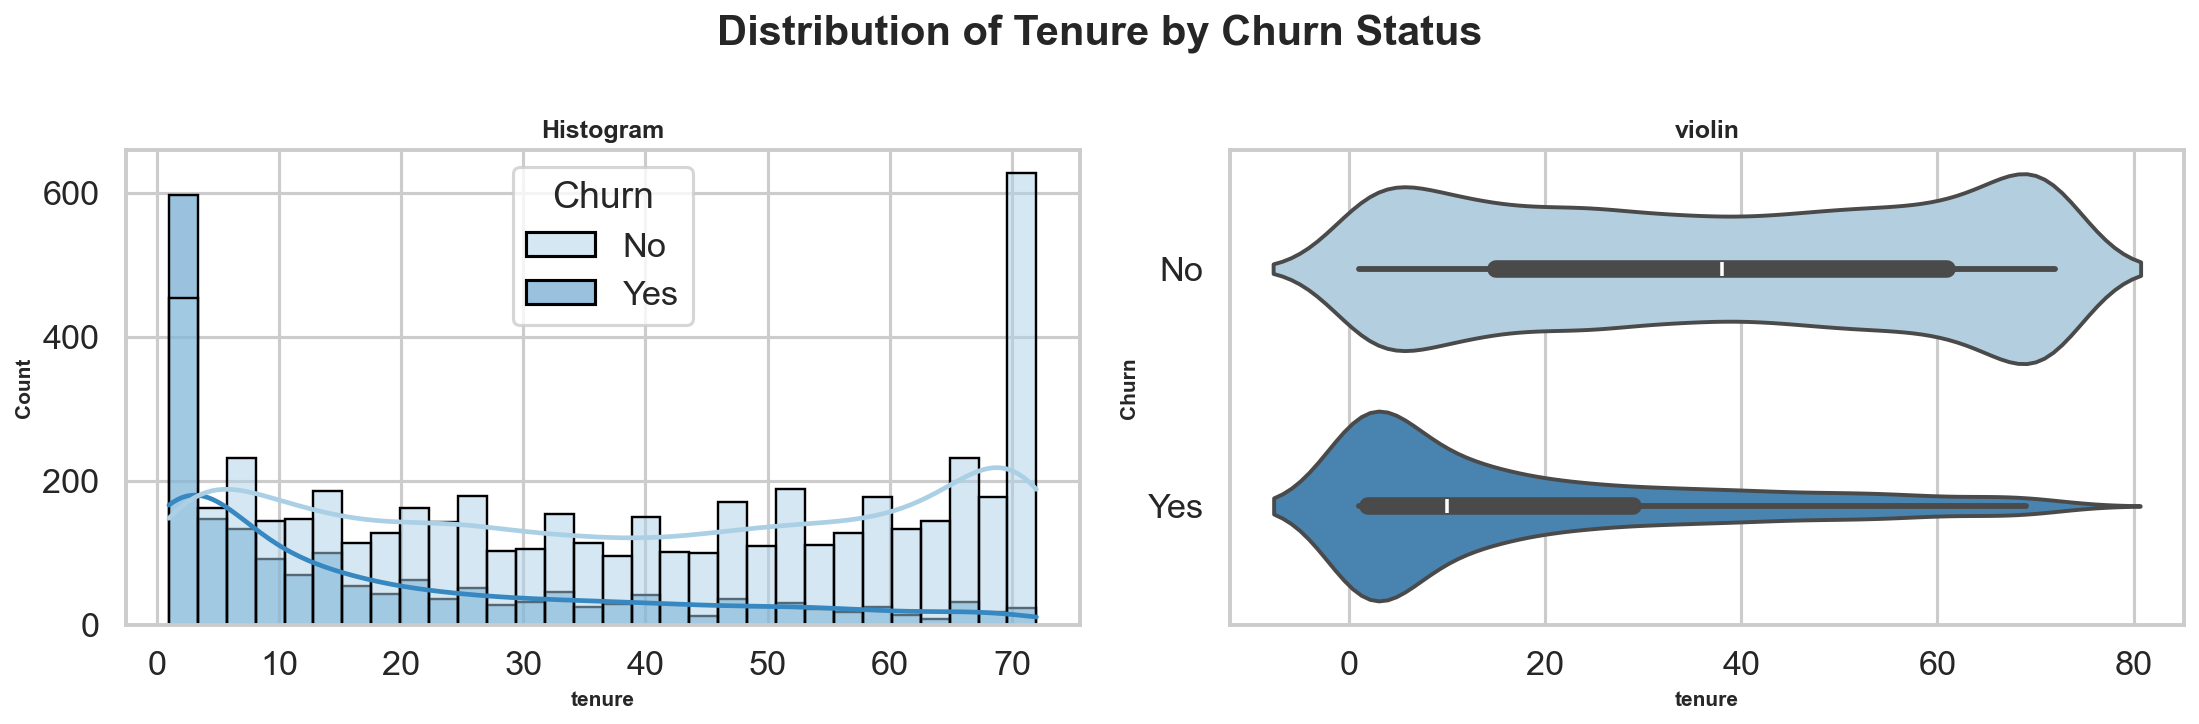

In [74]:
fig, axes = plt.subplots(figsize=(15, 5), ncols=2)
axes = axes.ravel()

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0], 
             palette=PALETTE, bins=30, edgecolor='black', alpha=0.5)

sns.violinplot(data=df, x='tenure', y='Churn', hue='Churn', 
               palette=PALETTE, ax=axes[1])

plt.suptitle('Distribution of Tenure by Churn Status', fontsize=SUP_TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)

for ax in axes:
    ax.set_xlabel(ax.get_xlabel(), fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
    
axes[0].set_title('Histogram', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
axes[0].set_ylabel('Count', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)

axes[1].set_title('violin', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
axes[1].set_ylabel('Churn', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)

plt.tight_layout()
plt.show()

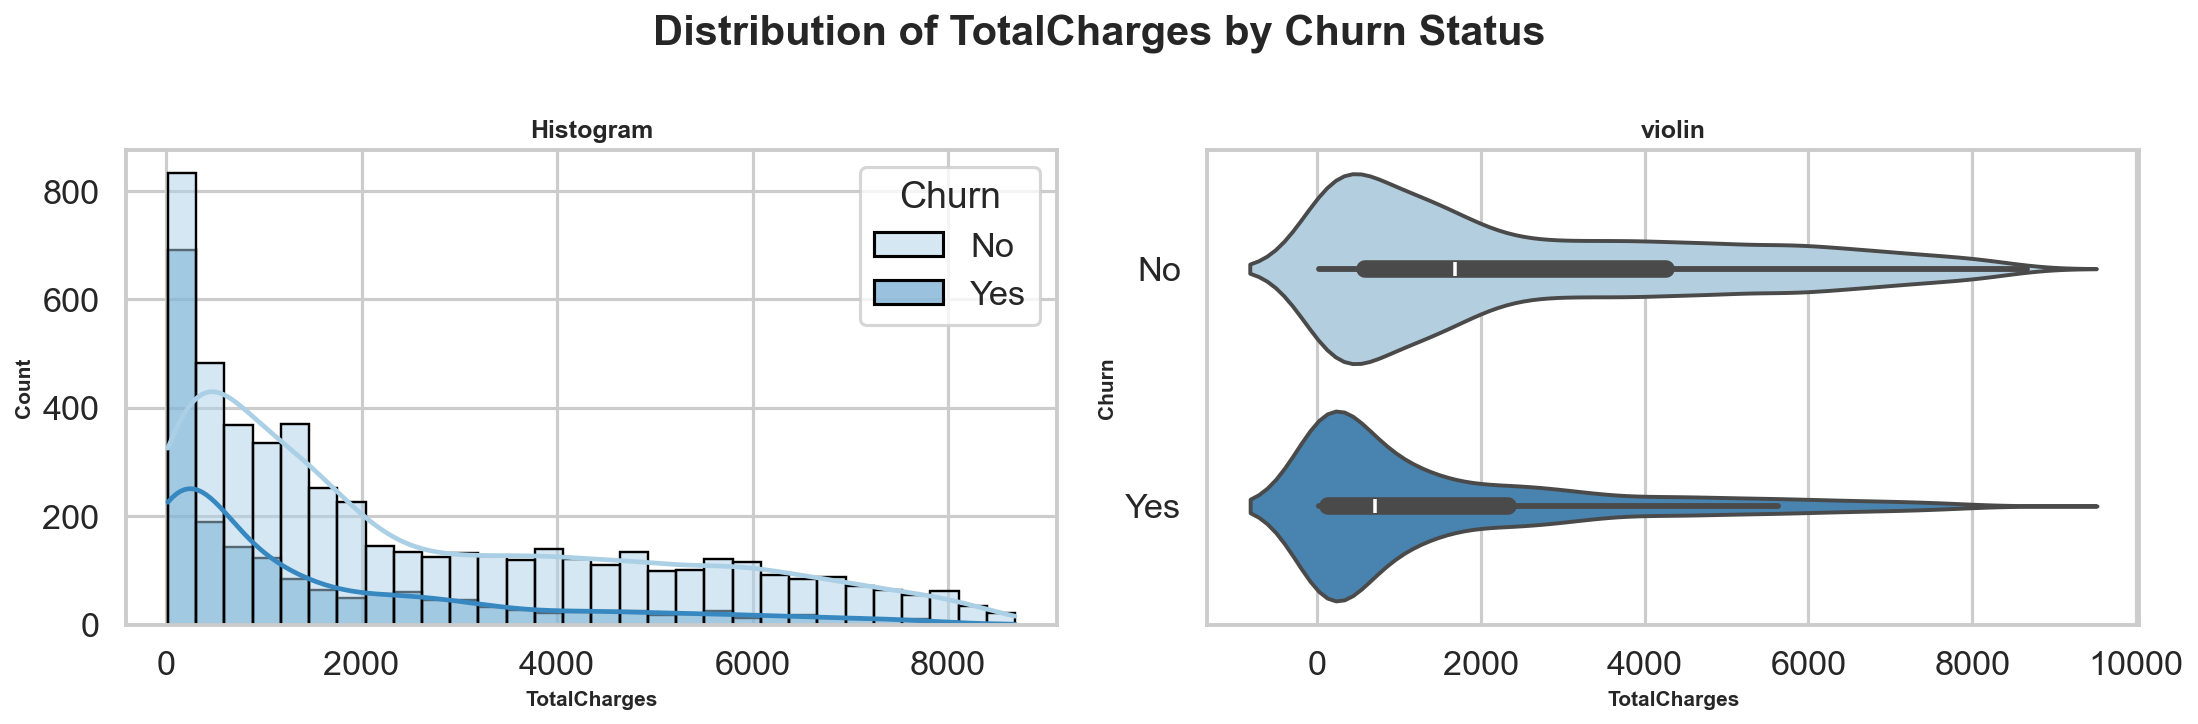

In [75]:
fig, axes = plt.subplots(figsize=(15, 5), ncols=2)
axes = axes.ravel()

sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, ax=axes[0], 
             palette=PALETTE, bins=30, edgecolor='black', alpha=0.5)

sns.violinplot(data=df, x='TotalCharges', y='Churn', hue='Churn', 
               palette=PALETTE, ax=axes[1])

plt.suptitle('Distribution of TotalCharges by Churn Status', fontsize=SUP_TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)

for ax in axes:
    ax.set_xlabel(ax.get_xlabel(), fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
    
axes[0].set_title('Histogram', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
axes[0].set_ylabel('Count', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)

axes[1].set_title('violin', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
axes[1].set_ylabel('Churn', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)

plt.tight_layout()
plt.show()

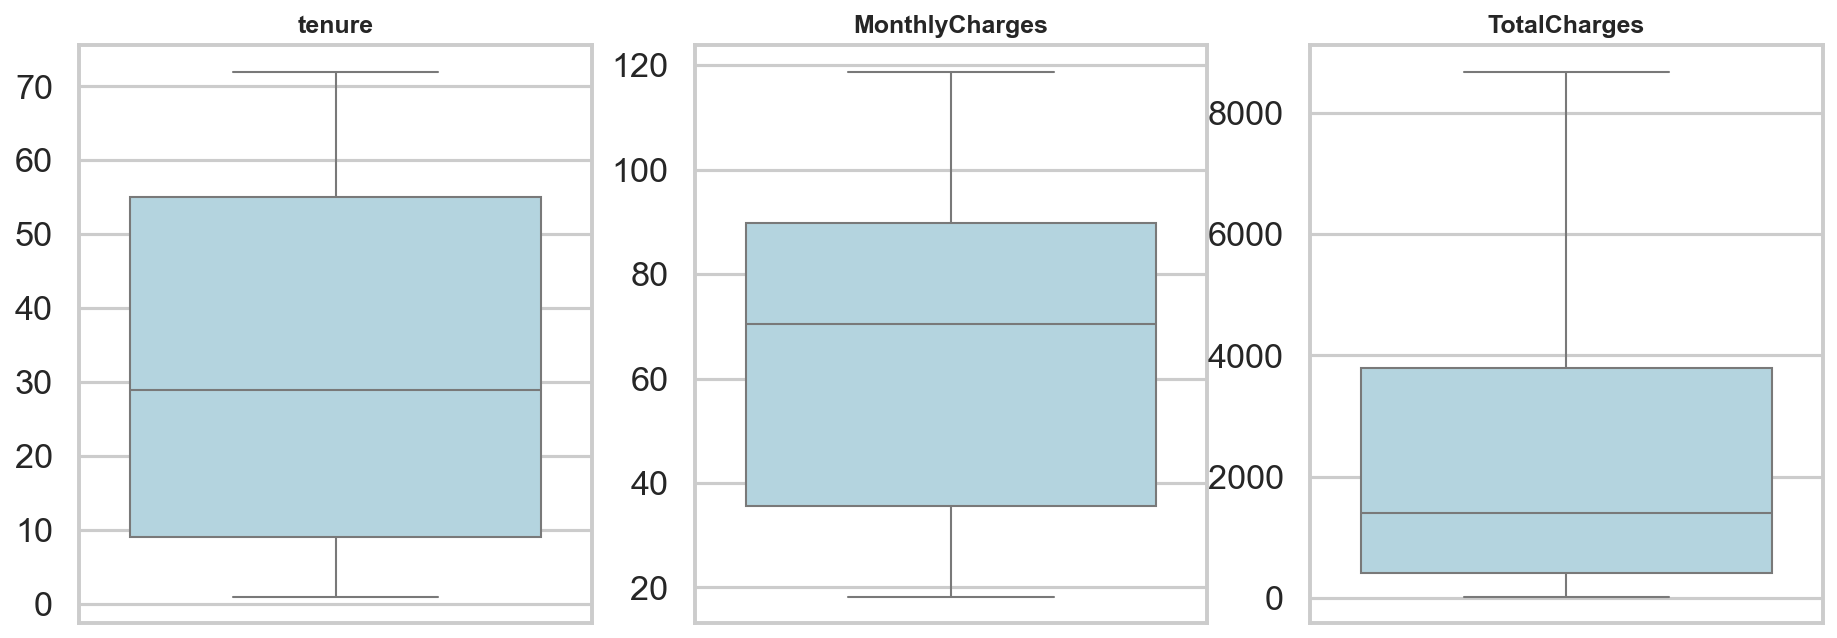

In [76]:
fig, axes = plt.subplots(figsize=(15, 5), ncols=3, nrows=1)
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(df, y=col, ax=ax, color=COLOR)
    
    ax.set_title(col, fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.set_ylabel('')

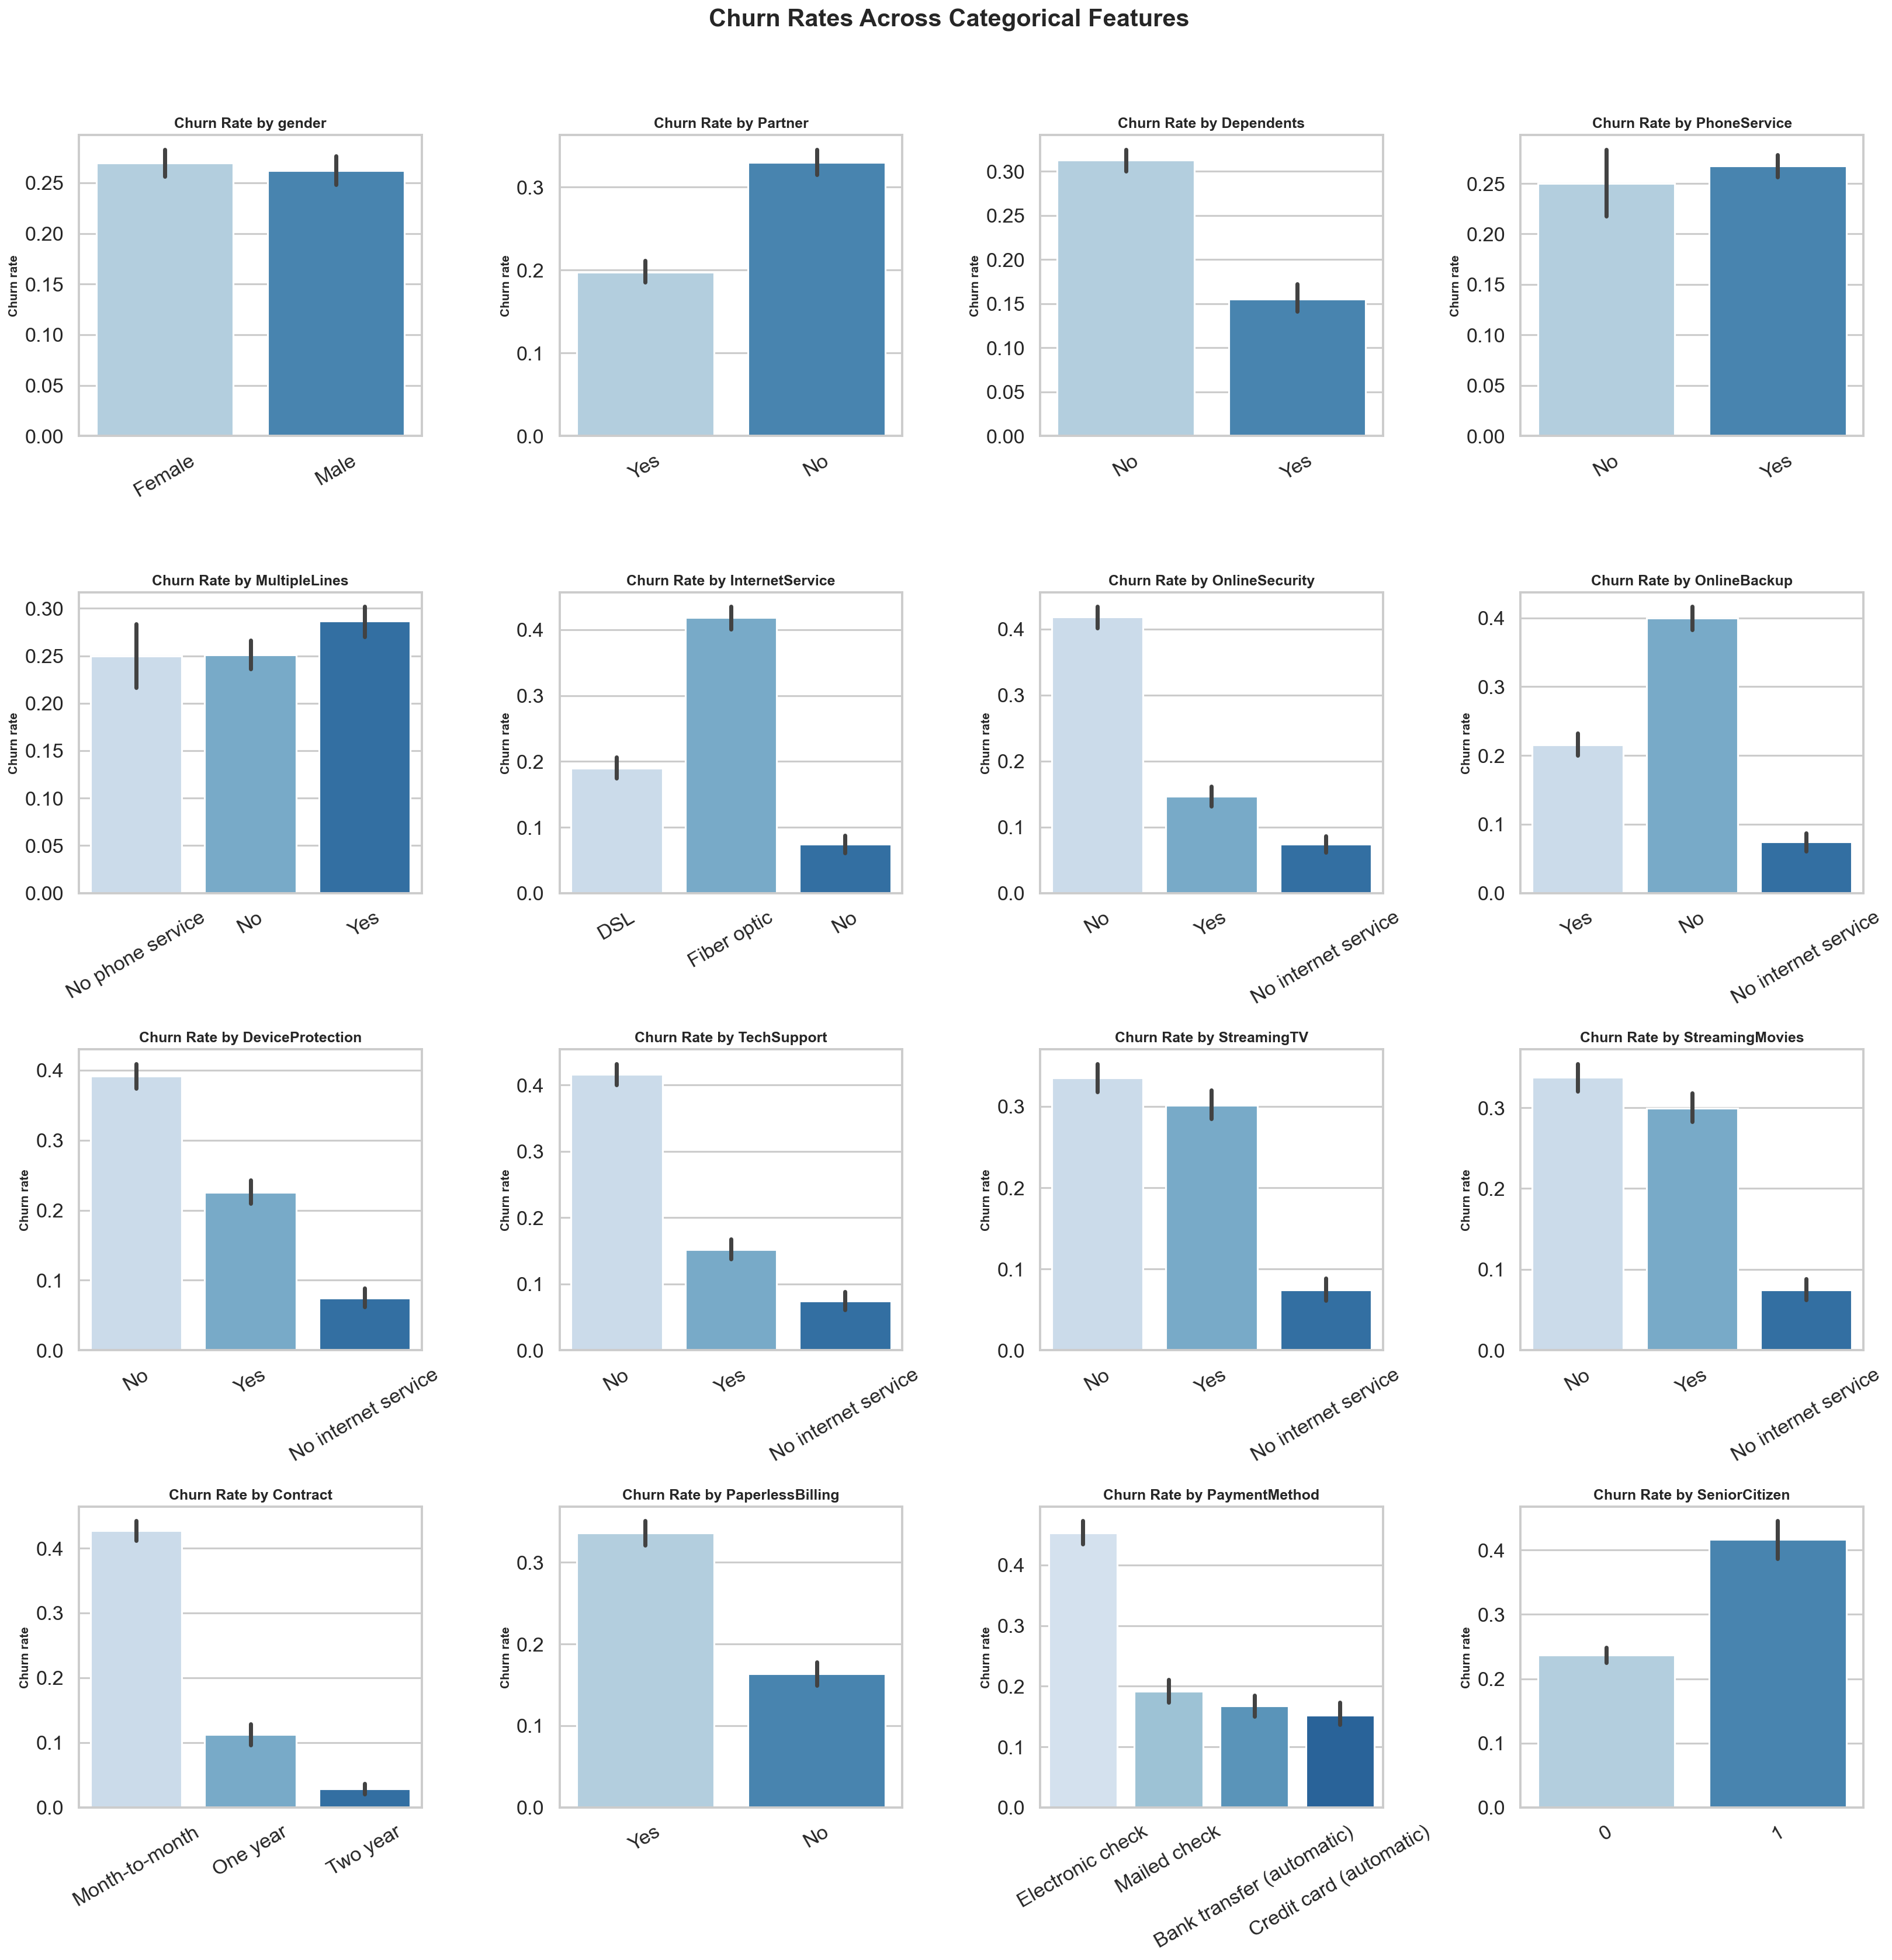

In [77]:
fig, axes = plt.subplots(figsize=(22, 22), nrows=4, ncols=4)
axes = axes.ravel()

for ax, col in zip(axes, categorical_cols):
    sns.barplot(data=df, x=col, y=df['Churn']=='Yes', ax=ax, palette=PALETTE, hue=col, legend=False)
    
    ax.set_title(f"Churn Rate by {col}", fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.set_xlabel("")
    ax.set_ylabel("Churn rate", fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Churn Rates Across Categorical Features', fontsize=SUP_TITLE_FONT_SIZE, fontweight=FONT_WEIGHT, y=1.02)
plt.subplots_adjust(wspace=0.30, hspace=0.35)
plt.tight_layout()
plt.show()

## Research Questions

1. Which type of Contract has the highest Churn, and why?  
2. What is the relationship between tenure and churn?  
3. Does MonthlyCharges have a strong relationship with churn?  
4. How much do the security services (OnlineSecurity, TechSupport) affect churn?  
5. Which PaymentMethod has the highest churn?  
6. How does being a SeniorCitizen influence churn?

### 1. Which type of Contract has the highest Churn, and why?  

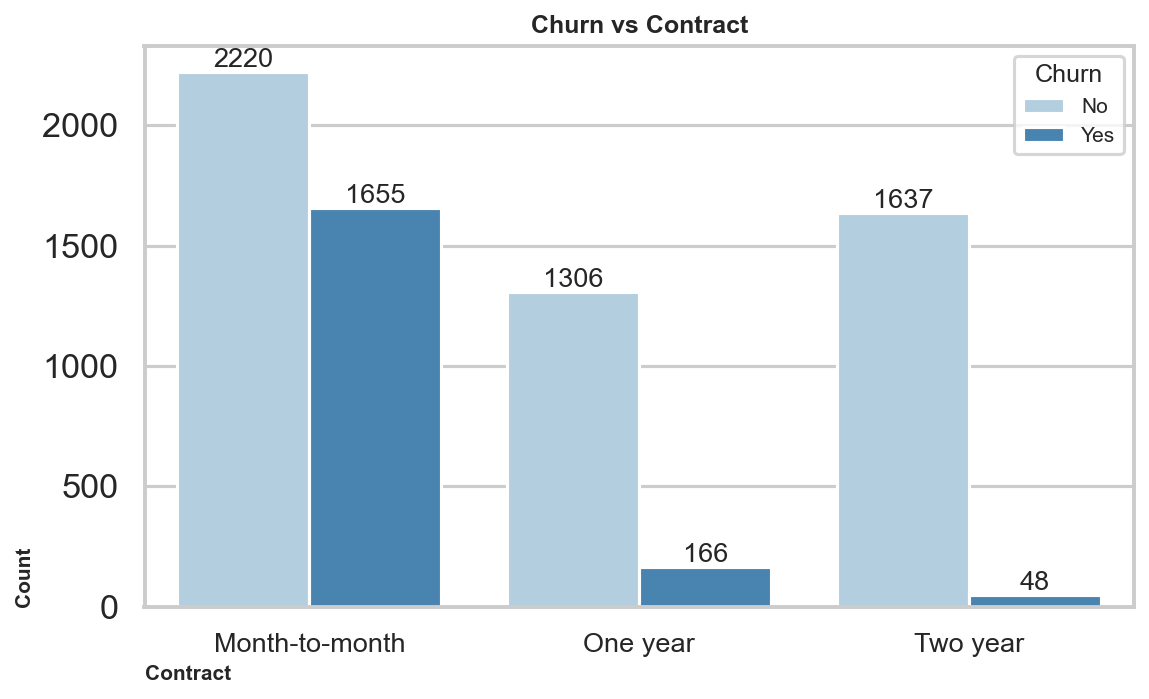

In [78]:
churn_rate_by_contract = df.groupby('Contract', as_index=False)['Churn'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bar = sns.barplot(data=churn_rate_by_contract, x='Contract', y='count', hue='Churn', palette=PALETTE)

for container in bar.containers:
    ax.bar_label(container, fontsize=13)

ax.set_title('Churn vs Contract', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xlabel('Contract', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT, loc='left')
ax.set_ylabel('Count', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT, loc='bottom')
ax.tick_params(axis='x', labelsize=13)

plt.legend(loc='upper right', title='Churn', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

<p>
    <b>Result:</b> Customers with <b>month-to-month</b> contracts have the highest churn rate.
</p>
<p>
    <b>Why:</b> This occurs primarily because these contracts carry no long-term commitment, allowing customers to cancel or switch to competitors at any time without financial penalties.
     Many users also choose monthly plans as a trial phase when they are uncertain about the service quality, leading to higher turnover if their expectations are not immediately met.
</p>


### 2. What is the relationship between tenure and churn?

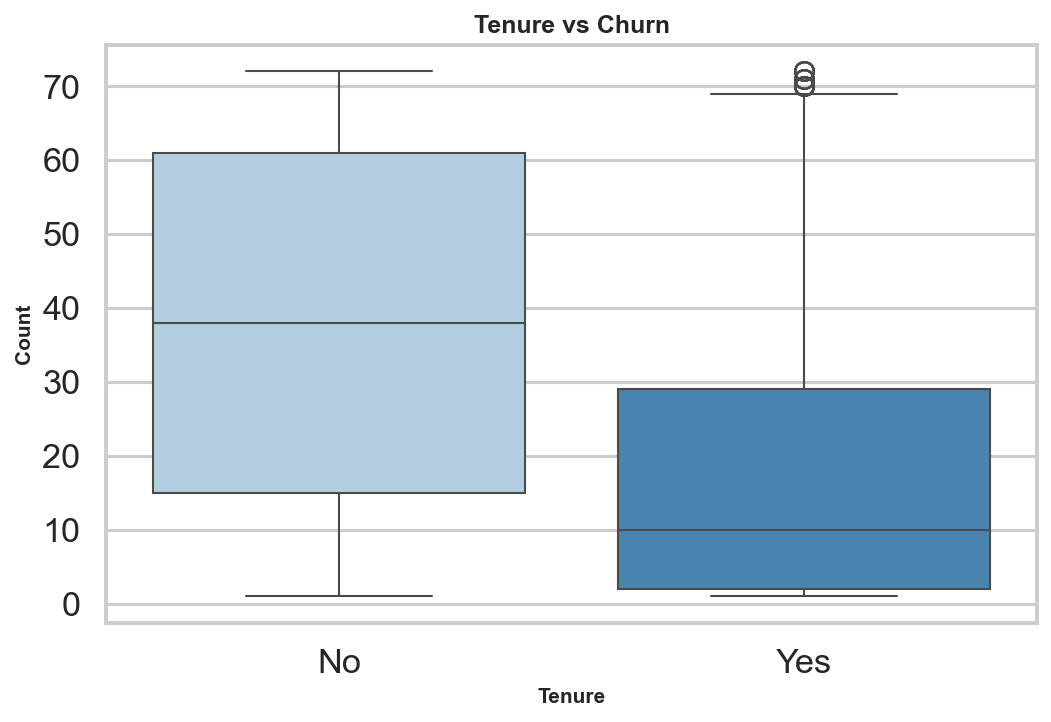

In [79]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, y="tenure", x="Churn", ax=ax, hue='Churn', palette=PALETTE)

ax.set_title("Tenure vs Churn", fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xlabel('Tenure', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_ylabel('Count', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)

plt.show()

<p>
    <b>Result:</b> There is a clear negative correlation between tenure and churn. Customers who churn ("Yes") typically have a much shorter tenure, with a low median, while loyal customers ("No") have stayed with the company for a significantly longer duration.
</p>
<p>
    <b>Why:</b> New customers are at the highest risk, likely due to a poor onboarding experience or an initial mismatch between expectations and service quality. Once customers surpass a certain tenure threshold—roughly 30 to 40 months—they become much more stable, suggesting that they have successfully integrated the service into their daily routine or are satisfied with the long-term value, which drastically reduces the probability of them leaving.
</p>

### 3. How much do the security services (OnlineSecurity, TechSupport) affect churn?  

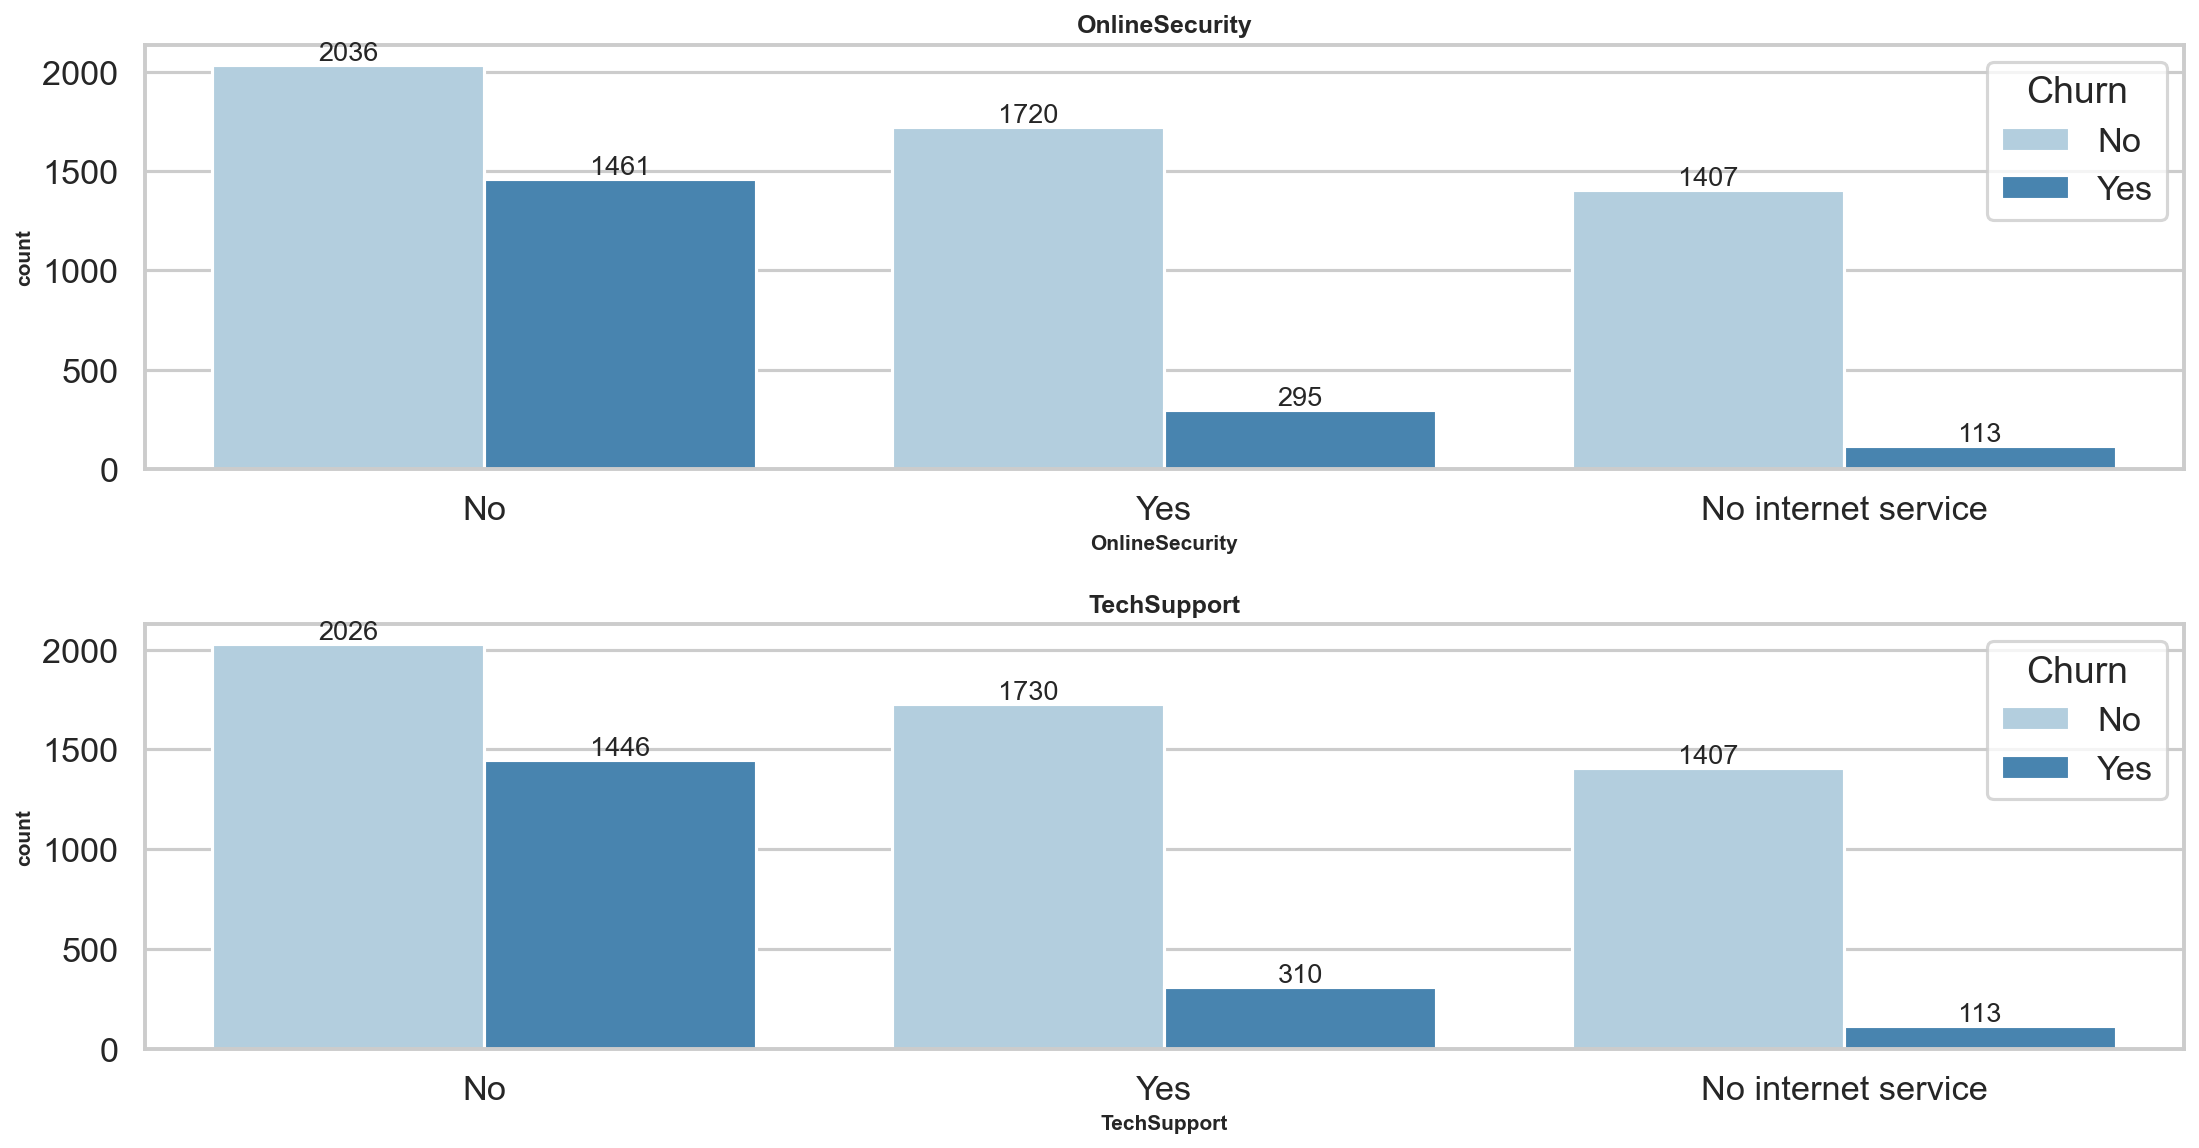

In [80]:
columns = ['OnlineSecurity', 'TechSupport']

fig, axes = plt.subplots(figsize=(15, 8), nrows=2, ncols=1)
axes = axes.flatten()

for ax, col in zip(axes, columns):
    churn_rate = df.groupby('Churn', as_index=False)[col].value_counts()
    bar = sns.barplot(data=churn_rate, x=col, y='count', ax=ax, palette=PALETTE, hue='Churn')

    for container in bar.containers:
        ax.bar_label(container, fontsize=13)
        
    ax.set_title(col, fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.set_xlabel(ax.get_xlabel(), fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
    ax.set_ylabel(ax.get_ylabel(), fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)

plt.tight_layout()
plt.show()

<p><b>Result:</b> Security-related services have a strong association with churn. Customers without <b>OnlineSecurity</b> or <b>TechSupport</b> show a churn rate of ~42%, while customers who have these services churn at ~15%. Customers with <b>No internet service</b> have the lowest churn (~7%), likely because they belong to a different customer segment.</p>

### 4. Which PaymentMethod has the highest churn?  

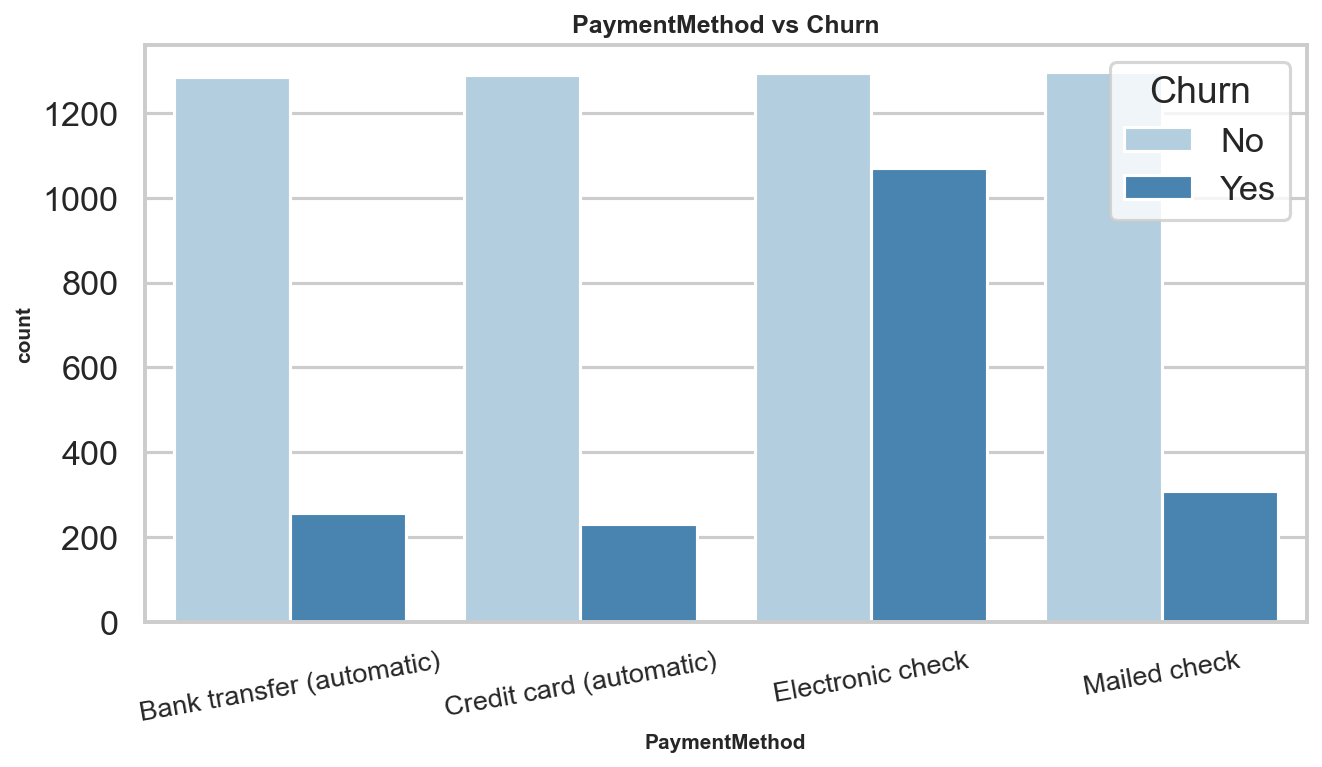

In [81]:
fig, ax = plt.subplots(figsize=(10, 5))

churn_rate = df.groupby('PaymentMethod', as_index=False)['Churn'].value_counts()

sns.barplot(data=churn_rate, x='PaymentMethod', y='count', ax=ax, palette=PALETTE, hue='Churn')

plt.title("PaymentMethod vs Churn", fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.xlabel(ax.get_xlabel(), fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.ylabel(ax.get_ylabel(), fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.xticks(rotation=10, fontsize=13)
plt.show()

<p><b>Result:</b> The highest churn is observed among customers who use <b>Electronic check</b> as their payment method, with a noticeably larger churn count compared to the other methods.</p>

### 5. How does being a SeniorCitizen influence churn?

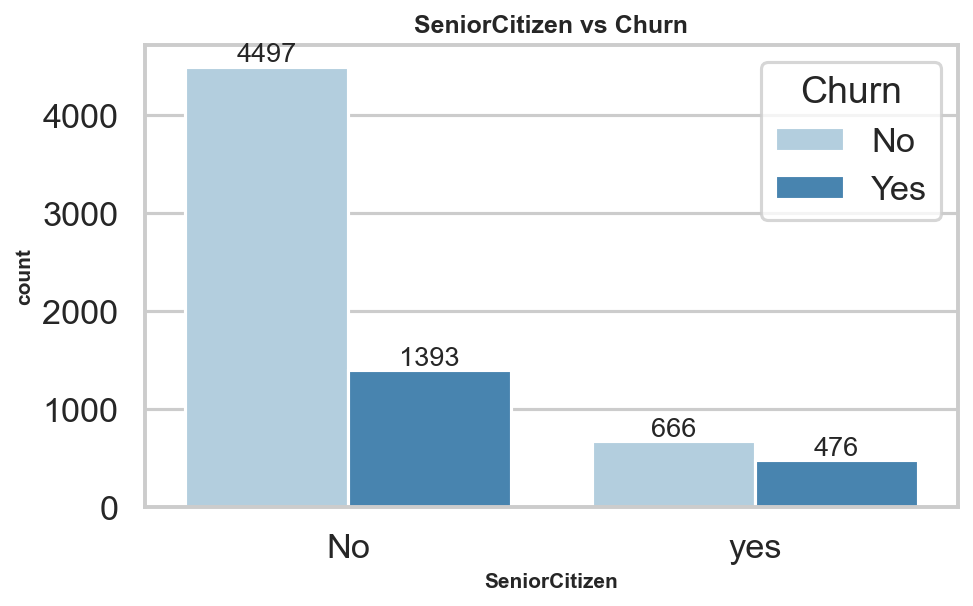

In [82]:
churn_rate_by_senior_citizen = df.groupby('Churn', as_index=False)['SeniorCitizen'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))

bar = sns.barplot(
    data=churn_rate_by_senior_citizen,
    x='SeniorCitizen', y='count',
    ax=ax, palette=PALETTE,
    hue='Churn', 
)

for container in bar.containers:
    ax.bar_label(container, fontsize=13)
    

plt.title("SeniorCitizen vs Churn", fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.xlabel(ax.get_xlabel(), fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.ylabel(ax.get_ylabel(), fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.xticks([0, 1], ['No', 'yes'])
plt.show()

<p><b>Result:</b> While the absolute number of senior citizens is much lower in the dataset, their <b>churn rate is significantly higher</b> compared to younger customers.</p>

<p><b>Why:</b> Approximately <b>41.7%</b> of senior citizens churn, whereas only about <b>23.6%</b> of non-seniors leave the service. This suggests that seniors are a higher-risk segment. This could be due to several factors such as fixed incomes making them more price-sensitive, or challenges with digital-only services. For our predictive model, <b>SeniorCitizen</b> is a critical feature because of this strong proportional disparity.</p>

## Training Model

In [83]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [84]:
transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), categorical_cols),
        ('scaler', StandardScaler(), numeric_cols)
    ]
)

X_prepared = transformer.fit_transform(X)

In [85]:
lb_encoder = LabelEncoder()
y = lb_encoder.fit_transform(y)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X_prepared, y, test_size=0.12, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(X_train.shape, X_test.shape, X_val.shape)

(4950, 46) (844, 46) (1238, 46)


In [87]:
pipe = imblearn_Pipeline([
    ("select", SelectFromModel(
        estimator=XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42
        ),
    )),
    ('resample', SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])


param_dist = {
    "select__threshold": ["median", "mean"],
    "model__n_estimators": [200, 300, 400, 500, 700, 1000, 2000, 5000],
    "model__max_depth": [3, 4, 5, 6, 7],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.3, 0.5, 1],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0.5, 1, 2, 5],
}

cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=100,
    cv=cv,
    random_state=42,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
best_model = random_search.best_estimator_

print('Best AP Score:', random_search.best_score_)
print('Best parameters:', best_params)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best AP Score: 0.8444857983627342
Best parameters: {'select__threshold': 'median', 'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0.01, 'model__n_estimators': 700, 'model__min_child_weight': 7, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}


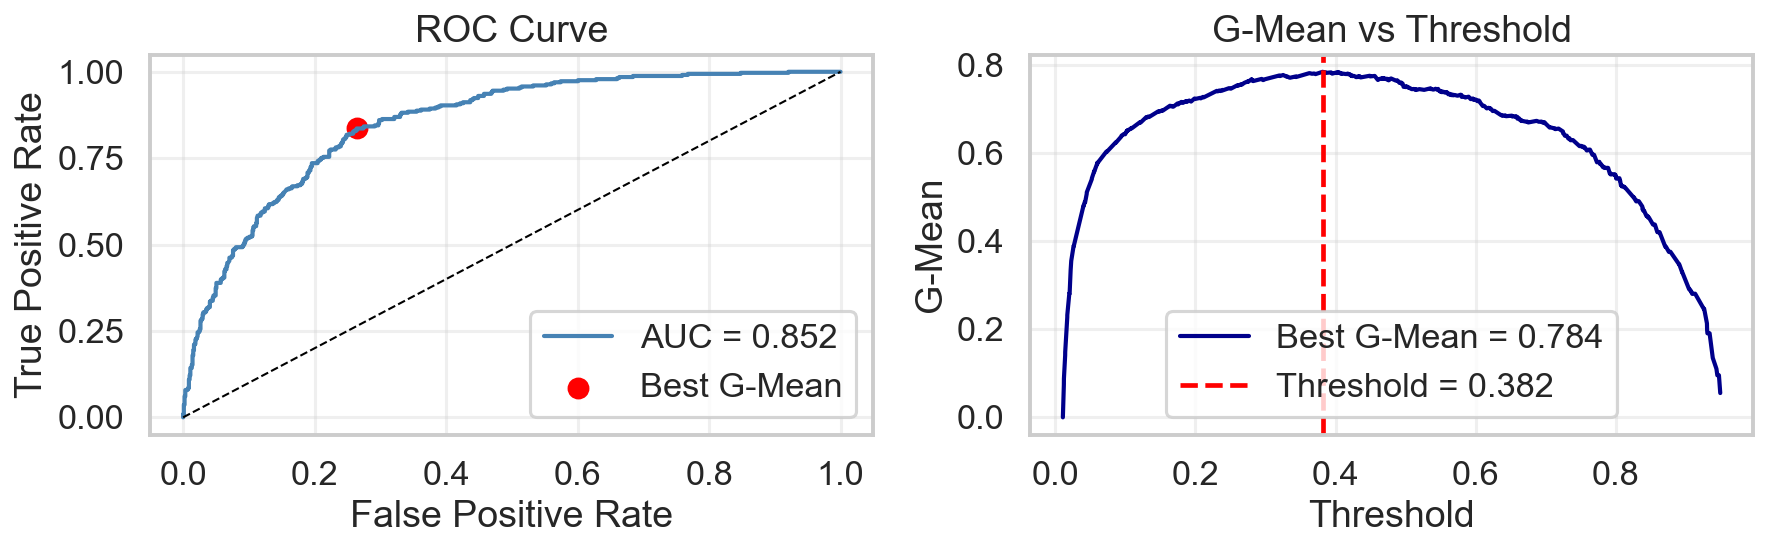

Best threshold: 0.38169205
Best G-Mean: 0.7843312433614061


In [88]:
y_proba_val = best_model.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_proba_val)
roc_auc = roc_auc_score(y_val, y_proba_val)

g_mean = np.sqrt(tpr * (1 - fpr))

best_idx = np.argmax(g_mean)
best_threshold = thresholds[best_idx]
best_g_mean = g_mean[best_idx]

fig, ax = plt.subplots(figsize=(12, 4), nrows=1, ncols=2)

ax[0].plot(fpr, tpr, color='steelblue', linewidth=2,
           label=f'AUC = {roc_auc:.3f}')

ax[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
ax[0].scatter(fpr[best_idx], tpr[best_idx], color='red', label='Best G-Mean')

ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curve")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(thresholds, g_mean, color='darkblue', linewidth=2,
           label=f'Best G-Mean = {best_g_mean:.3f}')

ax[1].axvline(best_threshold, color='red', linestyle='--',
              label=f'Threshold = {best_threshold:.3f}')

ax[1].set_xlabel("Threshold")
ax[1].set_ylabel("G-Mean")
ax[1].set_title("G-Mean vs Threshold")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Best threshold:", best_threshold)
print("Best G-Mean:", best_g_mean)

In [89]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= best_threshold).astype(int)

f1_macro = f1_score(y_test, y_pred, average='macro')
roc_auc_score = roc_auc_score(y_test, y_pred, average='macro')

print("F1 Score:", f1_macro)
print("ROC AUC Score:", roc_auc_score)
print(classification_report(y_test, y_pred))

F1 Score: 0.7092402261046081
ROC AUC Score: 0.7617079493087557
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       620
           1       0.50      0.82      0.62       224

    accuracy                           0.74       844
   macro avg       0.71      0.76      0.71       844
weighted avg       0.80      0.74      0.75       844



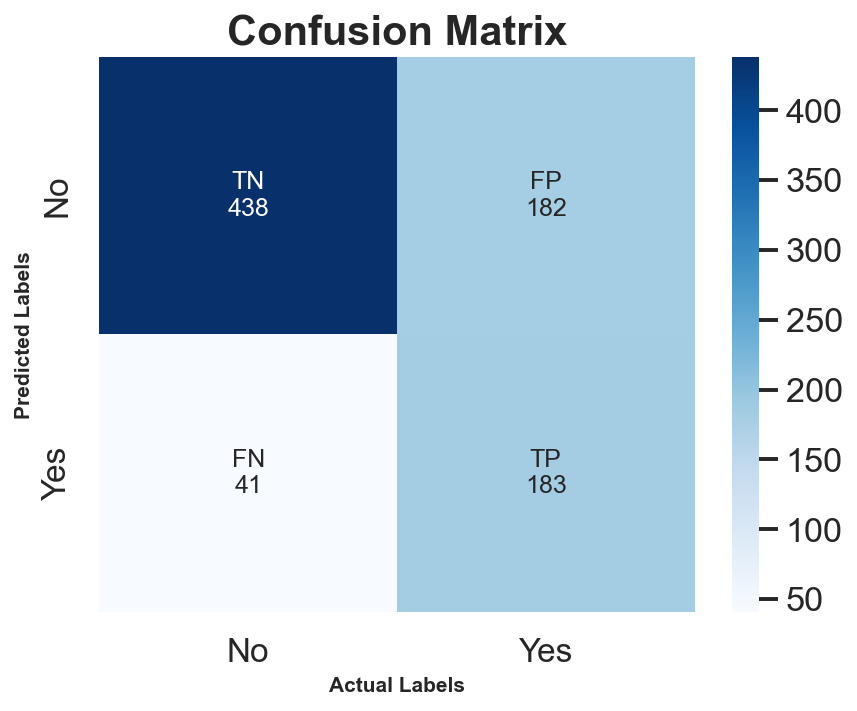

In [90]:
cf_matrix = confusion_matrix(y_test, y_pred)

labels = ['TN', 'FP', 'FN', 'TP']
ticks = ['No', 'Yes']
cf_matrix_values = cf_matrix.flatten()
cf_matrix_ticks = np.array([f'{lb}\n{val}' for lb, val in zip(labels, cf_matrix_values)]).reshape(-1, 2)

sns.heatmap(cf_matrix, fmt='', annot=cf_matrix_ticks, xticklabels=ticks,
            yticklabels=ticks, annot_kws={"size": 12}, cmap=PALETTE)

plt.title('Confusion Matrix', fontsize=SUP_TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.xlabel('Actual Labels', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.ylabel('Predicted Labels', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.tick_params(axis='both', labelsize=16)

plt.show()